# Actividad 1

Para esta actividad elegí el dataset Diabetes incluido en la librería sklearn.
Este conjunto de datos contiene información médica de pacientes y el objetivo es predecir una variable continua llamada target, que representa la progresión de la enfermedad.
La idea es usar distintas variables predictoras como edad, índice de masa corporal, presión sanguínea y mediciones séricas para intentar predecir ese valor objetivo mediante un modelo de regresión lineal.


---


En esta primera etapa se cargó el dataset y se organizó en un DataFrame de pandas. Luego se revisó su estructura general, la cantidad de filas y columnas, los tipos de datos y la existencia de valores faltantes.

El dataset no presenta valores nulos, por lo tanto no fue necesario eliminar ni reemplazar datos. Todas las variables son numéricas, lo cual facilita la aplicación de un modelo de regresión lineal.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

diabetes = load_diabetes()

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

df.head()
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


En la exploración de datos se analizó la distribución de la variable objetivo y la relación entre algunas variables predictoras y el valor que se desea predecir.

Se puede observar que algunas variables tienen mayor relación con el target, como bmi, s5 y bp. Esto indica que podrían ser variables importantes para el modelo de regresión lineal.

También se utilizó un gráfico de dispersión para observar si existe una relación entre el índice de masa corporal y la progresión de la enfermedad. Aunque la relación no es perfecta, sí parece existir una tendencia positiva.

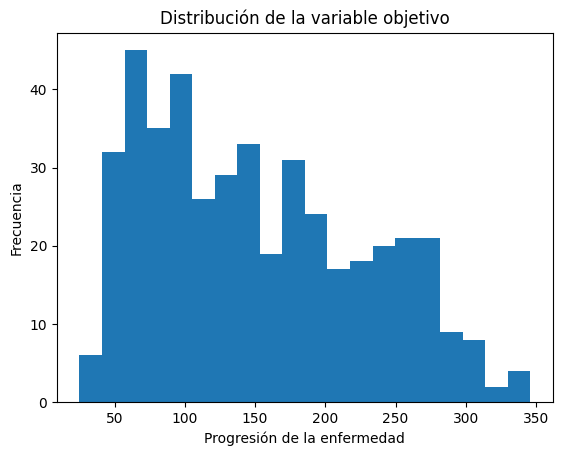

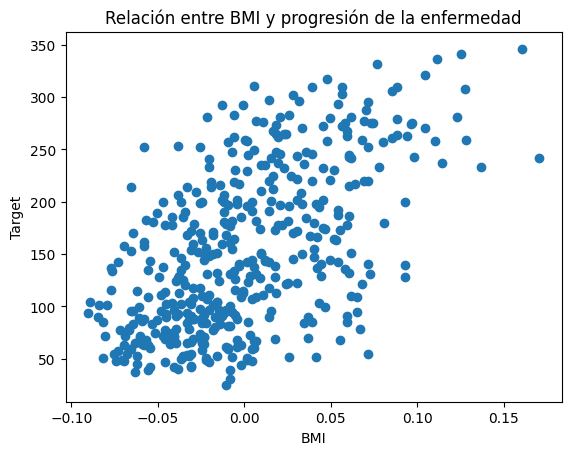

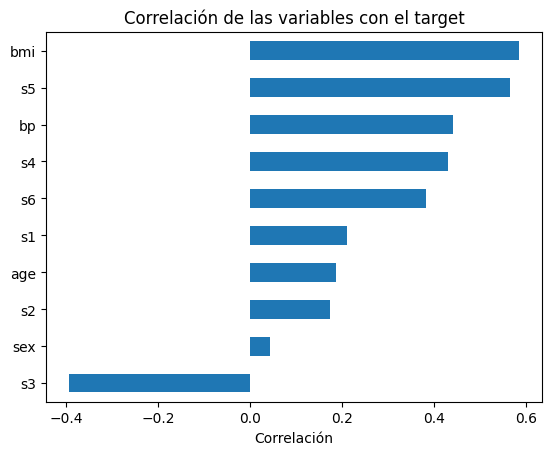

In [2]:
# Distribución de la variable objetivo
plt.hist(df["target"], bins=20)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Progresión de la enfermedad")
plt.ylabel("Frecuencia")
plt.show()

# Relación entre BMI y target
plt.scatter(df["bmi"], df["target"])
plt.title("Relación entre BMI y progresión de la enfermedad")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()

# Correlación entre variables
correlacion = df.corr()
correlacion["target"].sort_values(ascending=False)

# Gráfico simple de correlaciones con target
correlacion["target"].drop("target").sort_values().plot(kind="barh")
plt.title("Correlación de las variables con el target")
plt.xlabel("Correlación")
plt.show()

Se dividió el dataset en dos partes: un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utiliza para que el modelo aprenda la relación entre las variables predictoras y la variable objetivo. El conjunto de prueba se usa para evaluar cómo funciona el modelo con datos que no vio durante el entrenamiento.

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

X.head()
y.head()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape entrenamiento:", X_train.shape)
print("Shape prueba:", X_test.shape)

Shape entrenamiento: (353, 10)
Shape prueba: (89, 10)


Luego de entrenar el modelo, se realizaron predicciones sobre el conjunto de prueba. Para analizar el rendimiento, se compararon los valores reales con los valores predichos.

El gráfico permite observar qué tan cerca están las predicciones del modelo respecto de los valores reales. Si el modelo fuera perfecto, los puntos deberían estar muy alineados en forma diagonal. En este caso, se observa que el modelo logra captar cierta tendencia, aunque no predice con total exactitud.

In [4]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = modelo.predict(X_test)

y_pred[:10]



array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858])

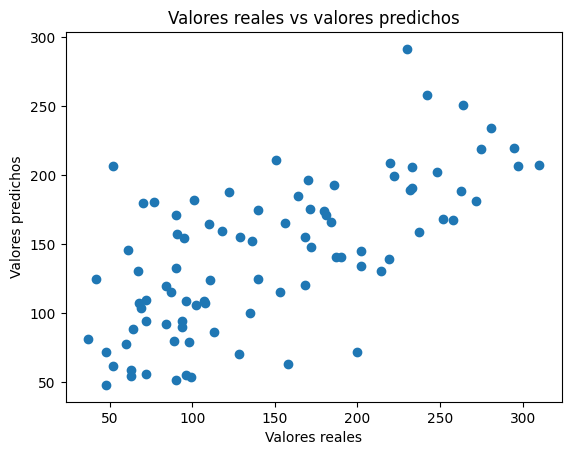

In [6]:
comparacion = pd.DataFrame({
    "Valor real": y_test,
    "Valor predicho": y_pred
})

comparacion.head(10)

plt.scatter(y_test, y_pred)
plt.title("Valores reales vs valores predichos")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.show()

In [7]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("Error absoluto medio:", mae)
print("Error cuadrático medio:", mse)
print("Raíz del error cuadrático medio:", rmse)
print("R2:", r2)

Error absoluto medio: 42.79409467959994
Error cuadrático medio: 2900.193628493482
Raíz del error cuadrático medio: 53.85344583676593
R2: 0.4526027629719195


Para evaluar el modelo se utilizaron distintas métricas. El error absoluto medio indica cuánto se equivoca aproximadamente el modelo en sus predicciones. En este caso, el error promedio fue de alrededor de 42.79 unidades.

El valor de R2 fue aproximadamente 0.45, lo que significa que el modelo logra explicar cerca del 45% de la variabilidad de la variable objetivo. Esto muestra que la regresión lineal tiene cierta capacidad predictiva, pero no es perfecta. Probablemente existan relaciones más complejas entre las variables que no pueden ser captadas completamente por un modelo lineal simple.

In [8]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
6,s3,163.419983
9,s6,48.670657
0,age,37.904021
1,sex,-241.964362
4,s1,-931.488846


Los coeficientes muestran el peso que tiene cada variable dentro del modelo. Un coeficiente positivo indica que, al aumentar esa variable, el valor predicho tiende a aumentar. Un coeficiente negativo indica lo contrario.

En este modelo, algunas variables como bmi y s5 tienen una influencia importante sobre la predicción del target.